# Helmholtz Equation with an Indefinite Spectrum

This notebook solves a small shifted Helmholtz-like linear system

$$(L-\sigma I)u=f,$$

where `L` is the Dirichlet negative Laplacian. Unlike Poisson, the shifted operator can have both positive and negative eigenvalues. That makes the example useful for discussing spectral gaps around zero and inverse-like transforms on an indefinite spectrum.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies an indefinite shifted Helmholtz operator.

**QSVT implementation.** It fits an odd inverse surrogate away from the spectral gap around zero. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** A direct solve validates the driven response. The example highlights the care needed for indefinite inverses: QSVT can target separated spectral branches, but the excluded gap and conditioning control accuracy.


## Variable definitions

- `n_points`: number of grid points.
- `x`, `L`: grid coordinates and Dirichlet negative-Laplacian matrix.
- `laplacian_eigenvalues`: eigenvalues of `L`.
- `sigma`: Helmholtz shift parameter.
- `H`: shifted Helmholtz operator.
- `helmholtz_eigenvalues`: eigenvalues of `H`.
- `scale`: spectral scale used to normalize `H`.
- `A`: rescaled Helmholtz operator.
- `gap`: excluded spectral neighborhood around zero.
- `source`: forcing vector.
- `fit_x`, `fit_target`: sampled inverse target for polynomial fitting.
- `coeffs`: fitted polynomial coefficients.
- `u_poly`, `u_direct`: polynomial and direct Helmholtz solutions.
- `relative_error`, `max_fit_error`: solution and polynomial-fit errors.
- `fig`, `axes`, `plot_x`, and similar names are plotting helpers.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

from qsvt.pde import dirichlet_laplacian_1d
from qsvt.polynomials import eval_polynomial
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_points = 10
x, L = dirichlet_laplacian_1d(n_points)
laplacian_eigenvalues, _ = eigh_hermitian(L)

sigma = 0.5 * (laplacian_eigenvalues[1] + laplacian_eigenvalues[2])
H = L - sigma * np.eye(n_points)
helmholtz_eigenvalues, _ = eigh_hermitian(H)

scale = np.max(np.abs(helmholtz_eigenvalues))
A = H / scale
gap = np.min(np.abs(np.linalg.eigvalsh(A)))

source = np.sin(np.pi * x) + 0.2 * np.sin(4.0 * np.pi * x)
print(f"First 4 Eigenvalues [inverse grid-length units]: {helmholtz_eigenvalues[:4]}")
print(f"Last Eigenvalue [inverse grid-length units]: {helmholtz_eigenvalues[-1]}")
print(f"Gap [model energy units]: {gap}")

First 4 Eigenvalues [inverse grid-length units]: [-51.1675 -22.5535  22.5535  80.4994]
Last Eigenvalue [inverse grid-length units]: 413.22712589466073
Gap [model energy units]: 0.05457901297346752


## Indefinite Helmholtz setup

Shifting the Laplacian creates positive and negative spectral branches, so the inverse polynomial excludes a gap around zero.


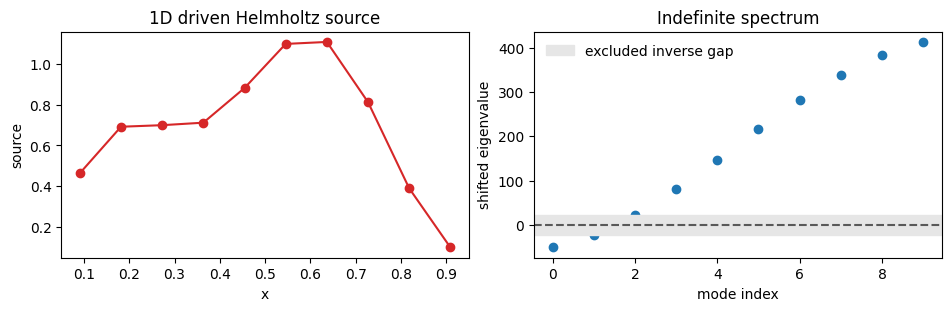

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.0), constrained_layout=True)

axes[0].plot(x, source, "o-", color="tab:red")
axes[0].set_xlabel("x")
axes[0].set_ylabel("source")
axes[0].set_title("1D driven Helmholtz source")

axes[1].scatter(
    np.arange(len(helmholtz_eigenvalues)), helmholtz_eigenvalues, color="tab:blue"
)
axes[1].axhline(0.0, color="0.35", linestyle="--")
axes[1].axhspan(-gap * scale, gap * scale, color="0.9", label="excluded inverse gap")
axes[1].set_xlabel("mode index")
axes[1].set_ylabel("shifted eigenvalue")
axes[1].set_title("Indefinite spectrum")
axes[1].legend(frameon=False)
plt.show()

## Fit an odd inverse surrogate away from zero

Because the rescaled operator has a spectral gap `[-gap, gap]` around zero, we fit the bounded target `gap / x` only on the two intervals actually relevant to the spectrum.

In [4]:
degree = 45
left = np.linspace(-1.0, -gap, 700)
right = np.linspace(gap, 1.0, 700)
fit_x = np.concatenate([left, right])
fit_target = gap / fit_x
with warnings.catch_warnings():
    warnings.simplefilter("ignore", np.exceptions.RankWarning)
    coeffs = np.polynomial.polynomial.polyfit(fit_x, fit_target, degree)

u_poly = apply_polynomial_to_hermitian(A, coeffs) @ source
u_poly = u_poly / (gap * scale)
u_direct = np.linalg.solve(H, source)

relative_error = np.linalg.norm(u_poly - u_direct) / np.linalg.norm(u_direct)
max_fit_error = np.max(np.abs(eval_polynomial(coeffs, fit_x) - fit_target))
print(f"Relative Error: {relative_error}")
print(f"Maximum Fit Error: {max_fit_error}")

Relative Error: 0.16873834910647584
Maximum Fit Error: 0.3658574904383274


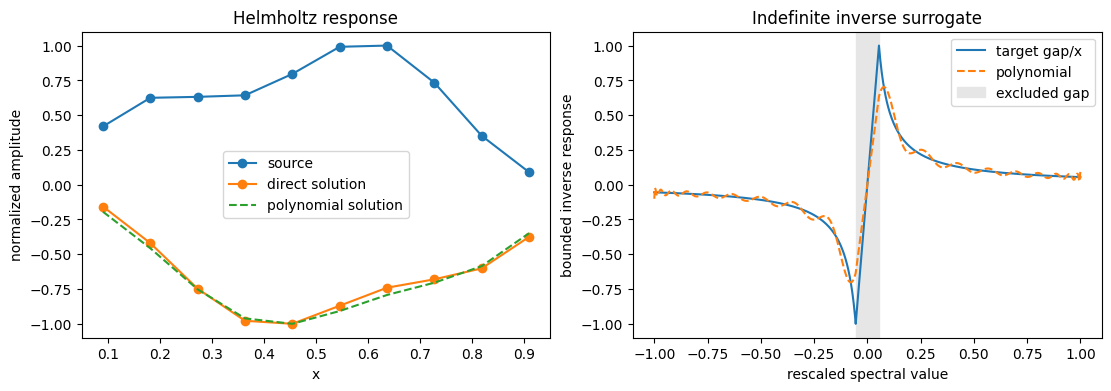

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)

axes[0].plot(x, source / np.max(np.abs(source)), "o-", label="source")
axes[0].plot(x, u_direct / np.max(np.abs(u_direct)), "o-", label="direct solution")
axes[0].plot(x, u_poly / np.max(np.abs(u_poly)), "--", label="polynomial solution")
axes[0].set_xlabel("x")
axes[0].set_ylabel("normalized amplitude")
axes[0].set_title("Helmholtz response")
axes[0].legend()

plot_x = np.concatenate([np.linspace(-1.0, -gap, 300), np.linspace(gap, 1.0, 300)])
axes[1].plot(plot_x, gap / plot_x, label="target gap/x")
axes[1].plot(plot_x, eval_polynomial(coeffs, plot_x), "--", label="polynomial")
axes[1].axvspan(-gap, gap, color="0.9", label="excluded gap")
axes[1].set_xlabel("rescaled spectral value")
axes[1].set_ylabel("bounded inverse response")
axes[1].set_title("Indefinite inverse surrogate")
axes[1].legend()

plt.show()

## Validation

Compact checks for the expected numerical behavior.

In [6]:
assert gap > 0.0
assert np.isfinite(relative_error)
assert np.isfinite(max_fit_error)
assert relative_error < 0.25
assert max_fit_error < 0.4
assert u_poly.shape == u_direct.shape == source.shape

print(f"spectral_gap [model energy units]: {gap:.3e}")
print(f"max_fit_error: {max_fit_error:.3e}")
print(f"relative_error: {relative_error:.3e}")
print("validation: passed")

spectral_gap [model energy units]: 5.458e-02
max_fit_error: 3.659e-01
relative_error: 1.687e-01
validation: passed
